# 整合演算法(Ensemble Learning)實驗:投票、Bagging、隨機森林與 Boosting

**這份筆記在做什麼?**

前幾份實驗都是「單一模型」。整合演算法的**基本思想**是:
**訓練時用多種分類器一起完成同一份任務;測試時讓待測樣本分別通過每個分類器,再彙總大家的結果。**
—— 三個臭皮匠,勝過一個諸葛亮。本實驗把主流的集成套路全部跑一遍。

**學習地圖:**

| 部分 | 主題 | 回答的問題 |
|:---:|---|---|
| 1 | 集成基本思想 + 投票策略 | 多個模型的意見怎麼彙總?硬投票、軟投票差在哪? |
| 2 | Bagging 與 OOB | 同一種模型怎麼「變出」多樣性?不切驗證集也能評估? |
| 3 | 隨機森林與特徵重要性 | 森林怎麼告訴我們哪些特徵重要? |
| 4 | Boosting(AdaBoost、GBDT) | 「知錯能改」的串行集成怎麼運作? |
| 5 | 提前停止 | Boosting 的樹要幾棵才夠? |
| 6 | Stacking | 用一個模型來「學會彙總」其他模型? |

> 💡 請**由上往下依序執行**每個 cell(Shift + Enter)。MNIST 相關的 cell 需要跑數十秒,屬正常現象。

## 0. 環境準備

In [1]:
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

# 統一圖表字體大小
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

import warnings
warnings.filterwarnings('ignore')   # 忽略警告訊息,保持輸出乾淨
np.random.seed(42)                  # 固定隨機種子,結果可重現

## 1. 集成基本思想與投票策略

### 1.1 基本思想

**訓練時**:用多種(或多個)分類器一起完成同一份任務 ——

![訓練階段:多種分類器各自學習同一份資料](./img/1.png)

**測試時**:對待測樣本分別通過不同的分類器,再**彙總**最後的結果(例如少數服從多數):

![測試階段:彙總各分類器的預測(多數決)](./img/2.png)

### 1.2 準備實驗資料

用 SVM 篇見過的彎月資料 `make_moons`(這次 500 筆、雜訊更大),並切出訓練/測試集:

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

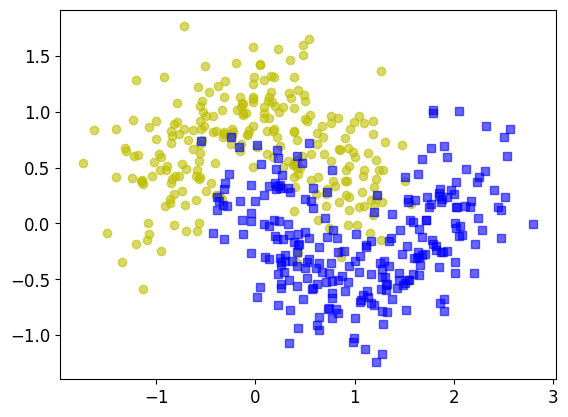

In [3]:
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'yo', alpha=0.6)   # 黃圓:類別 0
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs', alpha=0.6)   # 藍方塊:類別 1
plt.show()

雜訊比較大,兩類有明顯交錯 —— 正好考驗集成的威力。

### 1.3 投票策略:軟投票與硬投票

- **硬投票**:直接用類別值,**少數服從多數**
- **軟投票**:把各分類器的**機率值**進行加權平均,再取機率最大的類別

#### 硬投票實驗

準備三個「個性不同」的分類器:邏輯迴歸、隨機森林、SVM,再用 `VotingClassifier` 把它們包成一隊:

In [4]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

log_clf = LogisticRegression(random_state=42)
rnd_clf = RandomForestClassifier(random_state=42)
svm_clf = SVC(random_state=42)

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='hard')   # hard = 硬投票:少數服從多數

In [5]:
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

把三個單兵和投票隊伍的測試準確率都印出來比較:

In [6]:
from sklearn.metrics import accuracy_score

for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.864
RandomForestClassifier 0.896
SVC 0.896
VotingClassifier 0.912


**觀察結果:** 三個單一模型約 0.86~0.90,硬投票的組合**比任何一個單兵都高**(≈0.91)——
只要各模型犯錯的位置不完全相同,投票就能互相糾錯。

#### 軟投票實驗

改用機率平均。注意 `SVC` 預設不輸出機率,要開 `probability=True` ——
**軟投票要求每個分類器都能給出機率值**:

In [7]:
log_clf = LogisticRegression(random_state=42)
rnd_clf = RandomForestClassifier(random_state=42)
svm_clf = SVC(probability=True, random_state=42)   # 開啟機率輸出,SVC 才能參加軟投票

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='soft')   # soft = 軟投票:機率加權平均

In [8]:
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

In [9]:
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.864
RandomForestClassifier 0.896
SVC 0.896


VotingClassifier 0.92


**觀察結果:** 軟投票(≈0.92)又比硬投票高一點。

> 💡 軟投票用到了每個模型的「信心程度」(機率),資訊量比只看類別的硬投票多,通常表現更好;
> 代價是**每個分類器都必須能輸出機率值**。

## 2. Bagging 策略

投票用的是「不同種類」的模型。Bagging 走另一條路 —— 用**同一種模型**,靠**資料的隨機性**製造多樣性:

- 首先對訓練資料集進行多次**有放回採樣(bootstrap)**,保證每次得到的採樣資料都不同
- 分別訓練多個模型(例如樹模型)
- 預測時得到所有模型的結果,再進行集成(分類:投票)

![Bagging:對訓練集重複抽樣,並行訓練多個模型](./img/3.png)

In [10]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(),   # 基模型:決策樹
                  n_estimators=500,     # 一共 500 棵樹
                  max_samples=100,      # 每棵樹只看隨機抽出的 100 筆
                  bootstrap=True,       # 有放回採樣(= bootstrap)
                  n_jobs=-1,            # 用滿所有 CPU 平行訓練
                  random_state=42
)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

In [11]:
accuracy_score(y_test, y_pred)   # Bagging(500 棵樹)的測試準確率

0.904

和「一棵」不加限制的決策樹比比看:

In [12]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
accuracy_score(y_test, y_pred_tree)   # 單棵決策樹的測試準確率

0.856

### 2.1 決策邊界:集成與傳統方法對比

準確率 0.904 vs 0.856 —— 差在哪?把兩者的決策邊界畫出來(沿用之前的 meshgrid + contourf 套路):

In [13]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[-1.5, 2.5, -1, 1.5], alpha=0.5, contour=True):
    '''把分類器的決策區域填色畫出,並疊上訓練資料點'''
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
    plt.contourf(x1, x2, y_pred, cmap=custom_cmap, alpha=0.3)
    if contour:
        custom_cmap2 = ListedColormap(['#7d7d58', '#4c4c7f', '#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'yo', alpha=0.6)
    plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs', alpha=0.6)
    plt.axis(axes)
    plt.xlabel('x1')
    plt.ylabel('x2')

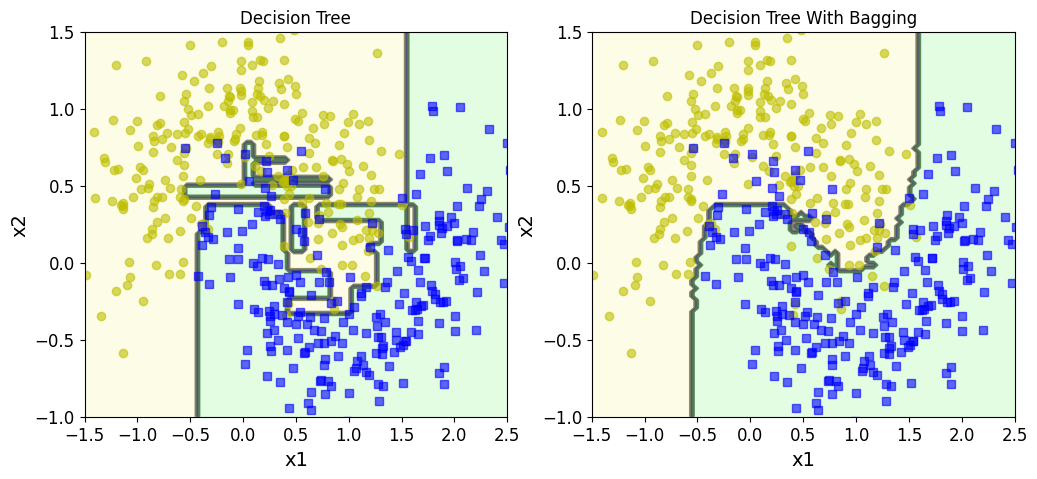

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(121)
plot_decision_boundary(tree_clf, X, y)
plt.title('Decision Tree')
plt.subplot(122)
plot_decision_boundary(bag_clf, X, y)
plt.title('Decision Tree With Bagging')
plt.show()

**觀察結果:** 左邊單棵樹的邊界支離破碎(過擬合,決策樹篇的老毛病);
右邊 Bagging 把 500 棵「各自過擬合」的樹平均起來,邊界明顯**平滑**、泛化更好 ——
**集成的威力主要來自「平均掉」單一模型的高變異**。

> 📖 Colormap 顏色參考:https://blog.csdn.net/zhaogeng111/article/details/78419015

### 2.2 OOB 策略(Out Of Bag)

有放回採樣有個免費贈品:每棵樹平均只會抽到約 63% 的樣本,**剩下約 37% 的樣本它從沒見過**(= Out of Bag)。
用「沒見過這筆資料的那些樹」來評估這筆資料,就得到**不需要另切驗證集**的評估分數:

In [15]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(),
                  n_estimators=500,
                  max_samples=100,
                  bootstrap=True,
                  n_jobs=-1,
                  random_state=42,
                  oob_score=True     # 開啟 OOB 評估
)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_                   # 用「袋外樣本」估出來的準確率

0.9253333333333333

In [16]:
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)       # 真正的測試集準確率,和 OOB 分數相當接近

0.904

In [17]:
bag_clf.oob_decision_function_   # 每筆訓練樣本的 OOB 機率估計 [P(類0), P(類1)]

array([[0.35579515, 0.64420485],
       [0.43243243, 0.56756757],
       [1.        , 0.        ],
       [0.01030928, 0.98969072],
       [0.03174603, 0.96825397],
       [0.07672634, 0.92327366],
       [0.39189189, 0.60810811],
       [0.06145251, 0.93854749],
       [0.92689295, 0.07310705],
       [0.88205128, 0.11794872],
       [0.59850374, 0.40149626],
       [0.04896907, 0.95103093],
       [0.7539267 , 0.2460733 ],
       [0.81377551, 0.18622449],
       [0.88528678, 0.11471322],
       [0.07407407, 0.92592593],
       [0.04738155, 0.95261845],
       [0.92051282, 0.07948718],
       [0.69974555, 0.30025445],
       [0.94358974, 0.05641026],
       [0.06100796, 0.93899204],
       [0.224     , 0.776     ],
       [0.9125964 , 0.0874036 ],
       [0.98746867, 0.01253133],
       [0.95967742, 0.04032258],
       [0.        , 1.        ],
       [0.94255875, 0.05744125],
       [1.        , 0.        ],
       [0.03466667, 0.96533333],
       [0.7020202 , 0.2979798 ],
       [0.

OOB 分數(0.925)和測試準確率(0.904)相當接近 —— OOB 是很實用的「免費驗證集」。

## 3. 隨機森林(Random Forest)

隨機森林 = **Bagging(基模型固定為決策樹) + 分裂時再隨機挑特徵**:
每個節點分裂時,不是看全部特徵,而是從隨機抽出的部分特徵中挑最好的 ——
「資料隨機 + 特徵隨機」雙重隨機,讓樹和樹之間更不一樣。sklearn 直接提供:

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### 3.1 特徵重要性

隨機森林附贈一個很實用的功能:**衡量每個特徵有多重要**。
可以粗略理解為:一個特徵在森林裡越常被用在**越靠近樹根**(越淺)的位置,它就越重要
(sklearn 實際上是把每個特徵帶來的不純度下降量做加權平均)。

用鳶尾花看看:

In [19]:
from sklearn.datasets import load_iris

iris = load_iris()
rf_clf = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)
rf_clf.fit(iris['data'], iris['target'])
for name, score in zip(iris['feature_names'], rf_clf.feature_importances_):
    print(name, score)

sepal length (cm) 0.11249225099876378
sepal width (cm) 0.02311928828251033
petal length (cm) 0.4410304643639577
petal width (cm) 0.42335799635476823


**觀察結果:** 花瓣(petal)長、寬兩個特徵合計超過 85% 的重要性,花萼(sepal)幾乎不重要 ——
和前幾份實驗「都挑花瓣特徵來用」的直覺一致。

### 3.2 MNIST 中哪些特徵(像素)比較重要呢?

MNIST 是 70,000 張 28×28 的手寫數字圖,每張圖攤平成 784 個像素 = 784 個特徵。
訓練一個隨機森林,再把 784 個特徵重要性**排回 28×28 的圖**,就能看出模型都在看哪些位置:

In [20]:
from pathlib import Path
from scipy.io import loadmat
from sklearn.utils import Bunch

mnist_path = Path('mnist-original.mat')
if not mnist_path.exists():
    mnist_path = Path('隨機森林與整合演算法-實驗') / 'mnist-original.mat'
mnist_mat = loadmat(mnist_path)
mnist = Bunch(data=mnist_mat['data'].T, target=mnist_mat['label'].ravel().astype(np.uint8))

# 快速實驗版:只取部分 MNIST,避免完整 70,000 筆訓練太久。
rng = np.random.RandomState(42)
subset_idx = rng.choice(len(mnist.data), size=10000, replace=False)
mnist = Bunch(data=mnist.data[subset_idx], target=mnist.target[subset_idx])

In [21]:
rf_clf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
rf_clf.fit(mnist['data'], mnist['target'])

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [22]:
rf_clf.feature_importances_.shape   # 784 個特徵,對應 28×28 個像素

(784,)

In [23]:
def plot_digit(data):
    '''把 784 維向量排回 28x28 圖片顯示'''
    image = data.reshape(28, 28)
    plt.imshow(image, cmap=matplotlib.cm.hot)
    plt.axis('off')

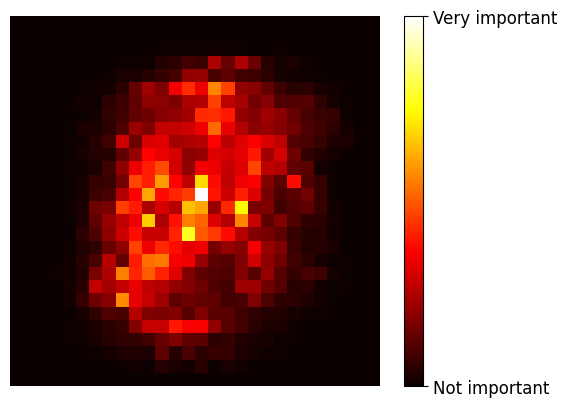

In [24]:
plot_digit(rf_clf.feature_importances_)
char = plt.colorbar(ticks=[rf_clf.feature_importances_.min(), rf_clf.feature_importances_.max()])
char.ax.set_yticklabels(['Not important', 'Very important'])
plt.show()

**觀察結果:** 越亮的像素越重要 —— 重要的特徵集中在**圖片中央**(數字筆畫出現的地方),
四周邊緣幾乎全黑(邊緣永遠是空白,對分類毫無幫助)。

> 💡 特徵重要性是隨機森林最常用的附加價值之一:實務上常先用森林掃一遍特徵,把不重要的砍掉。

## 4. Boosting:提升策略

Bagging 的樹是**並行**、彼此獨立的;Boosting 反過來,**串行**地一個接一個訓練 ——
每個新模型都专注於修正前面模型犯的錯。

### 4.1 AdaBoost

想法就跟上學時的考試一樣:**這次做錯的題,下次是不是得額外注意,別再錯了!**
AdaBoost 每一輪訓練後,把**分錯的樣本權重調大**,讓下一個模型更在意這些難題:

![AdaBoost:逐輪加重錯分樣本的權重,串行修正](./img/4.png)

以 SVM 分類器為例,手動演示 AdaBoost 的基本策略(連續 5 輪,每輪把分錯樣本的權重放大;
左圖每輪放大 100%,右圖每輪放大 50%,數字 1~5 標出第幾輪的邊界):

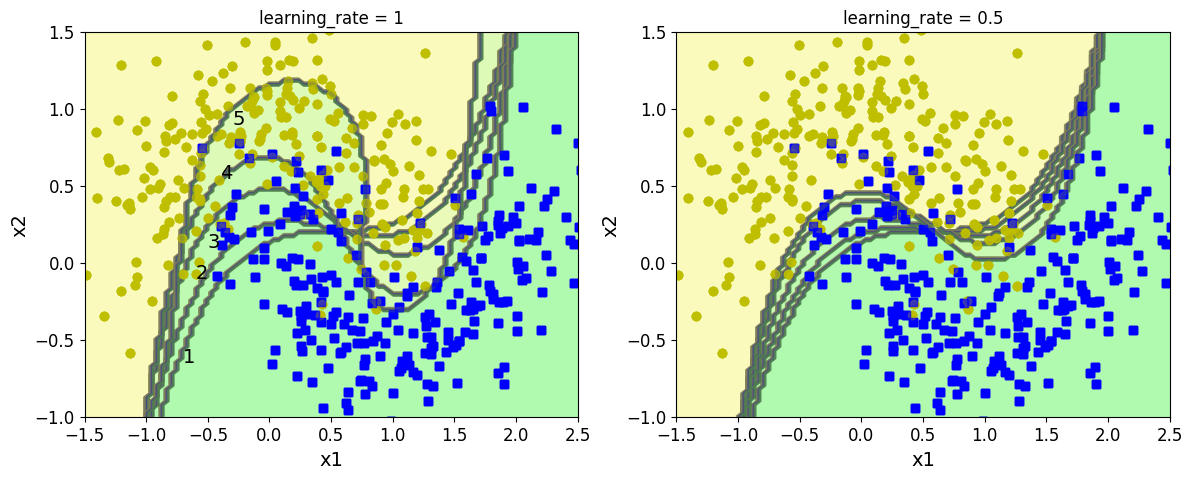

In [25]:
from sklearn.svm import SVC

m = len(X_train)

plt.figure(figsize=(14, 5))
for subplot, learning_rate in ((121, 1), (122, 0.5)):
    sample_weights = np.ones(m)                   # 初始:每筆樣本權重都是 1
    plt.subplot(subplot)
    for i in range(5):                            # 手動跑 5 輪
        svm_clf = SVC(kernel='rbf', C=0.05, random_state=42)
        svm_clf.fit(X_train, y_train, sample_weight=sample_weights)   # 帶權重訓練
        y_pred = svm_clf.predict(X_train)
        sample_weights[y_pred != y_train] *= (1 + learning_rate)      # 分錯的樣本 → 權重放大
        plot_decision_boundary(svm_clf, X, y, alpha=0.2)
        plt.title('learning_rate = {}'.format(learning_rate))
    if subplot == 121:
        plt.text(-0.7, -0.65, "1", fontsize=14)
        plt.text(-0.6, -0.10, "2", fontsize=14)
        plt.text(-0.5,  0.10, "3", fontsize=14)
        plt.text(-0.4,  0.55, "4", fontsize=14)
        plt.text(-0.3,  0.90, "5", fontsize=14)
plt.show()

**觀察結果:** 第 1 輪的邊界分錯不少點;隨著錯題權重加大,邊界一輪一輪被「推」往更合理的位置。
`learning_rate` 控制每輪加重的幅度:右圖(0.5)每輪修正得比較溫和。

sklearn 直接提供 `AdaBoostClassifier`(基模型用深度 1 的「樹樁」,一共 200 棵):

In [26]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),   # 每個基模型:一層的小樹
                   n_estimators=200,
                   learning_rate=0.5,
                   random_state=42
)

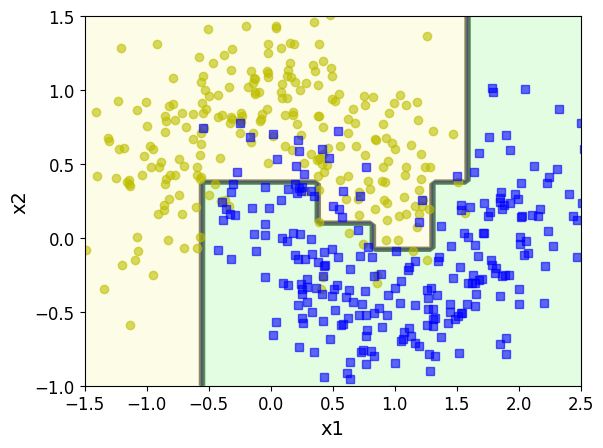

In [27]:
ada_clf.fit(X_train, y_train)
plot_decision_boundary(ada_clf, X, y)
plt.show()

200 棵「一層小樹」串起來,也能疊出一條像樣的彎曲邊界。

### 4.2 Gradient Boosting:擬合殘差

Boosting 的另一大家族。想法更直接:**下一棵樹,直接去擬合前面所有樹「還沒解釋掉的殘差」**。
先手動走一遍(迴歸任務):

In [28]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)   # 真實關係:拋物線 + 小雜訊

In [29]:
y.shape

(100,)

In [30]:
from sklearn.tree import DecisionTreeRegressor

In [31]:
tree_reg1 = DecisionTreeRegressor(max_depth=2)
tree_reg1.fit(X, y)                    # 第 1 棵樹:直接擬合 y

DecisionTreeRegressor(max_depth=2)

In [32]:
y2 = y - tree_reg1.predict(X)          # 殘差:y 還剩下多少沒被第 1 棵樹解釋掉
tree_reg2 = DecisionTreeRegressor(max_depth=2)
tree_reg2.fit(X, y2)                   # 第 2 棵樹:擬合這個殘差

DecisionTreeRegressor(max_depth=2)

In [33]:
y3 = y2 - tree_reg2.predict(X)         # 剩下的殘差再交給第 3 棵
tree_reg3 = DecisionTreeRegressor(max_depth=2)
tree_reg3.fit(X, y3)

DecisionTreeRegressor(max_depth=2)

預測時,把**所有樹的輸出相加**(每棵樹都是在「補」前面的不足):

In [34]:
X_new = np.array([[0.8]])
y_pred = sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))
y_pred

array([0.75026781])

畫成六宮格看整個過程:**左欄**是每棵樹各自學到的東西(第 2、3 列的黑色 + 號是殘差),
**右欄**是「目前為止所有樹相加」的集成預測:

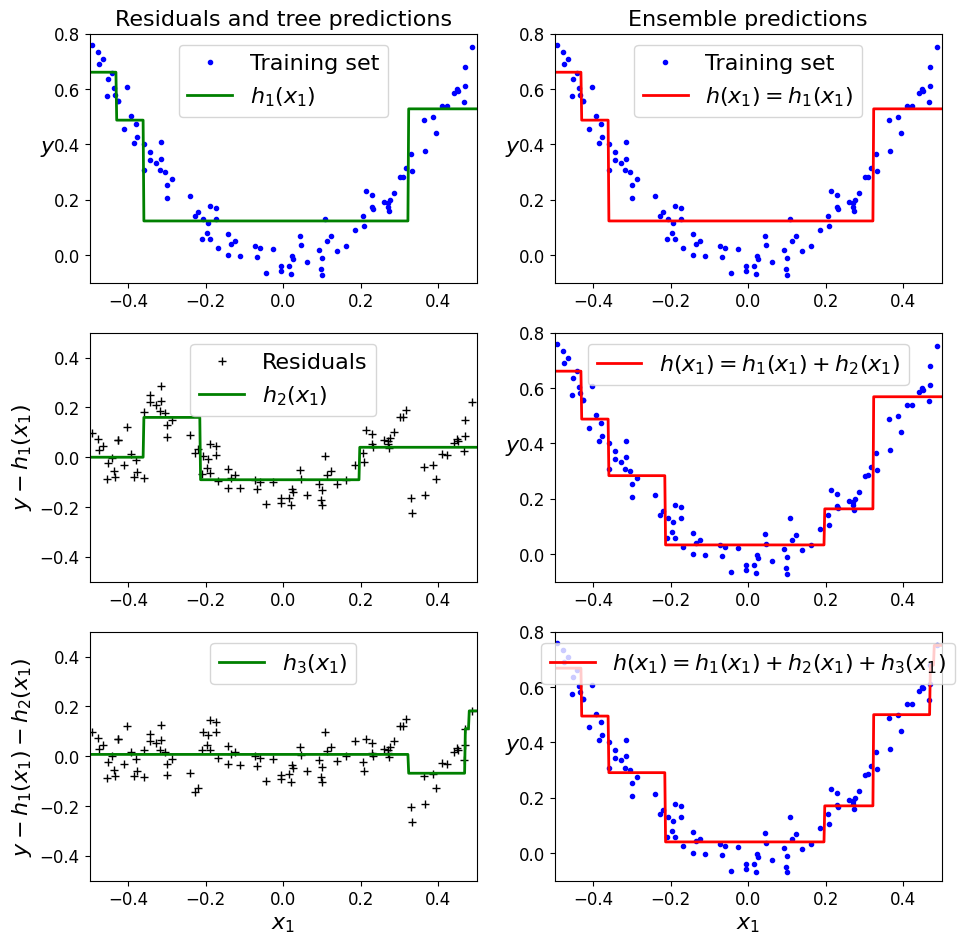

In [35]:
def plot_predictions(regressors, X, y, axes, label=None, style="r-", data_style="b.", data_label=None):
    '''畫出資料點,以及「多個迴歸器輸出相加」的預測曲線'''
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1)) for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center", fontsize=16)
    plt.axis(axes)

plt.figure(figsize=(11, 11))

plt.subplot(321)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="$h_1(x_1)$", style="g-", data_label="Training set")
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.title("Residuals and tree predictions", fontsize=16)

plt.subplot(322)
plot_predictions([tree_reg1], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="$h(x_1) = h_1(x_1)$", data_label="Training set")
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.title("Ensemble predictions", fontsize=16)

plt.subplot(323)
plot_predictions([tree_reg2], X, y2, axes=[-0.5, 0.5, -0.5, 0.5], label="$h_2(x_1)$", style="g-", data_style="k+", data_label="Residuals")
plt.ylabel("$y - h_1(x_1)$", fontsize=16)

plt.subplot(324)
plot_predictions([tree_reg1, tree_reg2], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="$h(x_1) = h_1(x_1) + h_2(x_1)$")
plt.ylabel("$y$", fontsize=16, rotation=0)

plt.subplot(325)
plot_predictions([tree_reg3], X, y3, axes=[-0.5, 0.5, -0.5, 0.5], label="$h_3(x_1)$", style="g-", data_style="k+")
plt.ylabel("$y - h_1(x_1) - h_2(x_1)$", fontsize=16)
plt.xlabel("$x_1$", fontsize=16)

plt.subplot(326)
plot_predictions([tree_reg1, tree_reg2, tree_reg3], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label="$h(x_1) = h_1(x_1) + h_2(x_1) + h_3(x_1)$")
plt.xlabel("$x_1$", fontsize=16)
plt.ylabel("$y$", fontsize=16, rotation=0)

plt.show()

**觀察結果:** 右欄由上而下,集成的預測(紅線)一次比一次貼近資料 ——
每加一棵樹,就把殘差再啃掉一口。

### 4.3 GradientBoostingRegressor 與學習率

sklearn 的 `GradientBoostingRegressor` 把上面的流程包好了,
`learning_rate` 控制**每棵樹的貢獻被縮小多少**(收縮量),試三種組合:

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

In [37]:
gbrt = GradientBoostingRegressor(max_depth=2,
                          n_estimators=3,        # 3 棵樹
                          learning_rate=1.0,     # 每棵樹全額貢獻
                          random_state=41
)
gbrt.fit(X, y)

GradientBoostingRegressor(learning_rate=1.0, max_depth=2, n_estimators=3,
                          random_state=41)

In [38]:
gbrt_slow_1 = GradientBoostingRegressor(max_depth=2,
                          n_estimators=3,        # 3 棵樹
                          learning_rate=0.1,     # 每棵只貢獻 10%
                          random_state=41
)
gbrt_slow_1.fit(X, y)

GradientBoostingRegressor(max_depth=2, n_estimators=3, random_state=41)

In [39]:
gbrt_slow_2 = GradientBoostingRegressor(max_depth=2,
                          n_estimators=200,      # 200 棵樹
                          learning_rate=0.1,
                          random_state=41
)
gbrt_slow_2.fit(X, y)

GradientBoostingRegressor(max_depth=2, n_estimators=200, random_state=41)

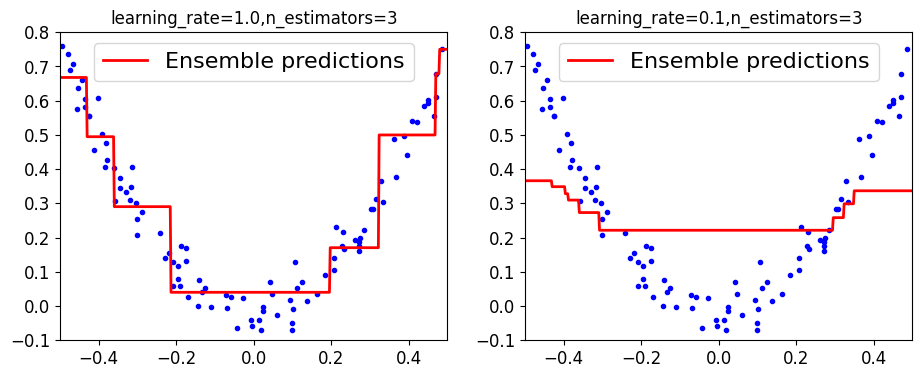

In [40]:
plt.figure(figsize=(11, 4))
plt.subplot(121)
plot_predictions([gbrt], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label='Ensemble predictions')
plt.title('learning_rate={},n_estimators={}'.format(gbrt.learning_rate, gbrt.n_estimators))

plt.subplot(122)
plot_predictions([gbrt_slow_1], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label='Ensemble predictions')
plt.title('learning_rate={},n_estimators={}'.format(gbrt_slow_1.learning_rate, gbrt_slow_1.n_estimators))
plt.show()

**觀察結果:** 同樣 3 棵樹,`learning_rate=0.1`(右)每棵只貢獻 10%,三棵加起來遠遠不夠 —— 嚴重欠擬合。
**學習率調低,就必須用更多的樹來補**:

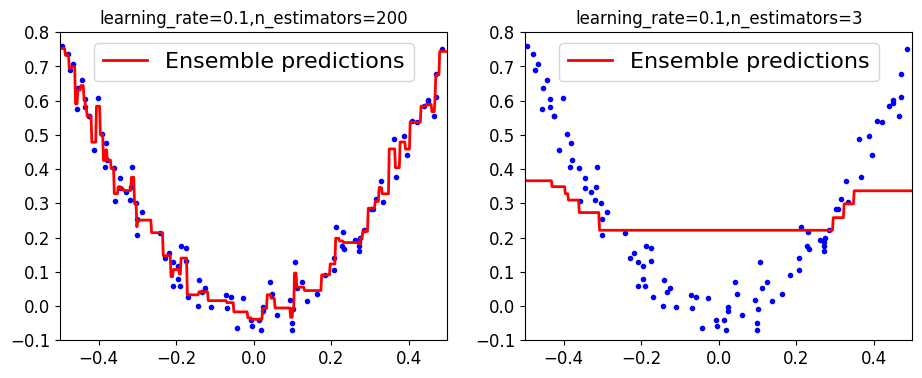

In [41]:
plt.figure(figsize=(11, 4))
plt.subplot(121)
plot_predictions([gbrt_slow_2], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label='Ensemble predictions')
plt.title('learning_rate={},n_estimators={}'.format(gbrt_slow_2.learning_rate, gbrt_slow_2.n_estimators))

plt.subplot(122)
plot_predictions([gbrt_slow_1], X, y, axes=[-0.5, 0.5, -0.1, 0.8], label='Ensemble predictions')
plt.title('learning_rate={},n_estimators={}'.format(gbrt_slow_1.learning_rate, gbrt_slow_1.n_estimators))
plt.show()

左圖:同樣學習率 0.1,給足 200 棵樹就擬合得很好(甚至開始有一點過擬合的跡象)。

> 💡 `learning_rate` 和 `n_estimators` 是一對蹺蹺板:**低學習率 + 較多的樹**通常泛化較好,但訓練較慢。
> 那樹到底要幾棵?—— 下一節的提前停止來回答。

## 5. 提前停止策略

還記得線性迴歸篇結尾提過的概念嗎?**一邊訓練一邊監控驗證誤差,誤差開始回升就停** ——
Boosting 的樹是一棵一棵加的,天生適合這招。

**做法一:先全部訓練完,再回放。** `staged_predict` 會回放「只用前 1 棵、前 2 棵、…」時的預測,
逐一算驗證誤差,挑出最低點:

In [42]:
from sklearn.metrics import mean_squared_error

X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=49)

gbrt = GradientBoostingRegressor(max_depth=2,
                          n_estimators=120,     # 先一口氣訓練 120 棵
                          random_state=42
)
gbrt.fit(X_train, y_train)

# 回放:分別用前 1,2,...,120 棵樹預測驗證集,記錄每一步的誤差
errors = [mean_squared_error(y_val, y_pred) for y_pred in gbrt.staged_predict(X_val)]
bst_n_estimators = np.argmin(errors)            # 驗證誤差最低的樹數

# 用最佳樹數重新訓練一個「剛剛好」的模型
gbrt_best = GradientBoostingRegressor(max_depth=2,
                          n_estimators=bst_n_estimators,
                          random_state=42
)
gbrt_best.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=np.int64(55),
                          random_state=42)

In [43]:
min_error = np.min(errors)
min_error   # 最低驗證誤差

np.float64(0.002712853325235463)

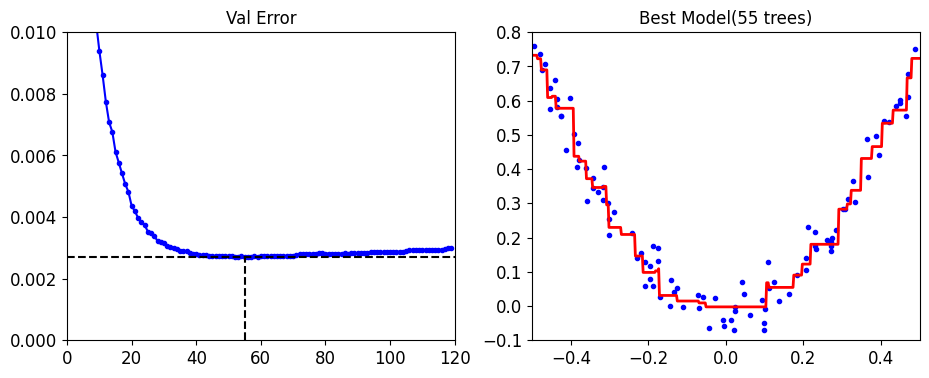

In [44]:
plt.figure(figsize=(11, 4))
plt.subplot(121)
plt.plot(errors, 'b.-')
plt.plot([bst_n_estimators, bst_n_estimators], [0, min_error], 'k--')   # 最佳樹數的位置
plt.plot([0, 120], [min_error, min_error], 'k--')
plt.axis([0, 120, 0, 0.01])
plt.title('Val Error')

plt.subplot(122)
plot_predictions([gbrt_best], X, y, axes=[-0.5, 0.5, -0.1, 0.8])
plt.title('Best Model(%d trees)' % bst_n_estimators)
plt.show()

**觀察結果:** 驗證誤差先快速下降、在 55 棵左右觸底,之後**緩慢回升**(開始過擬合)——
最佳模型就取 55 棵。

**做法二:真正的「邊訓練邊停」。** 用 `warm_start=True` 讓模型保留已訓練的樹、逐棵往上加;
連續 5 次驗證誤差都沒創新低,就直接停:

In [45]:
gbrt = GradientBoostingRegressor(max_depth=2,
                             random_state=42,
                                 warm_start=True   # 保留舊樹,fit 時接著往上加
)
error_going_up = 0
min_val_error = float('inf')

for n_estimators in range(1, 120):
    gbrt.n_estimators = n_estimators
    gbrt.fit(X_train, y_train)                 # warm_start:只新增 1 棵,不重頭練
    y_pred = gbrt.predict(X_val)
    val_error = mean_squared_error(y_val, y_pred)
    if val_error < min_val_error:
        min_val_error = val_error              # 創新低:繼續
        error_going_up = 0
    else:
        error_going_up += 1
        if error_going_up == 5:                # 連續 5 次沒進步:停
            break

In [46]:
print(gbrt.n_estimators)   # 實際停在幾棵樹

61


兩種做法找到的位置相近(55 vs 61,後者多了 5 次「確認沒進步」的樹)。

## 6. Stacking(堆疊集成)

最後一招:投票是「規則式」的彙總(多數決/平均),Stacking 更進一步 ——
**訓練一個模型(blender)來學習「怎麼彙總」各家預測**:

![Stacking:用 blender 模型彙總各分類器的預測](./img/5.png)

訓練分兩階段(關鍵:blender 不能用第一層「見過」的資料訓練,否則會偏心):
第一層模型用子集 1 訓練;再對**子集 2** 做預測,這些預測值就變成 blender 的訓練特徵:

![兩階段訓練:第一層的預測結果變成 blender 的訓練資料](./img/6.png)

在 MNIST 上實作。先載入資料並切成**三份**:train(第一層訓練)/ val(產生 blender 的訓練資料)/ test(最終評估):

In [47]:
from pathlib import Path
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.utils import Bunch

mnist_path = Path('mnist-original.mat')
if not mnist_path.exists():
    mnist_path = Path('隨機森林與整合演算法-實驗') / 'mnist-original.mat'
mnist_mat = loadmat(mnist_path)
mnist = Bunch(data=mnist_mat['data'].T, target=mnist_mat['label'].ravel().astype(np.uint8))

# 快速實驗版:縮小訓練/驗證/測試集,保留 ensemble 流程但縮短等待時間。
rng = np.random.RandomState(42)
subset_idx = rng.choice(len(mnist.data), size=12000, replace=False)
mnist = Bunch(data=mnist.data[subset_idx], target=mnist.target[subset_idx])

X_train_val, X_test, y_train_val, y_test = train_test_split(
    mnist.data, mnist.target, test_size=2000, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=2000, random_state=42)

第一層:準備四個「個性不同」的模型(隨機森林、極端隨機樹、線性 SVM、神經網路):

In [48]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

In [49]:
random_forest_clf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=50, n_jobs=-1, random_state=42)
svm_clf = LinearSVC(max_iter=1000, random_state=42)
mlp_clf = MLPClassifier(hidden_layer_sizes=(50,), max_iter=50, random_state=42)

estimators = [random_forest_clf, extra_trees_clf, svm_clf, mlp_clf]

In [50]:
for estimator in estimators:
    print("Training the", estimator)
    estimator.fit(X_train, y_train)

Training the RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
Training the ExtraTreesClassifier(n_estimators=50, n_jobs=-1, random_state=42)


Training the LinearSVC(random_state=42)


Training the MLPClassifier(hidden_layer_sizes=(50,), max_iter=50, random_state=42)


第二階段:讓四個模型分別對**驗證集**做預測,把預測結果排成新的特徵矩陣
(每筆資料的新特徵 = 四個模型各自給它的答案):

In [51]:
X_val_predictions = np.empty((len(X_val), len(estimators)), dtype=np.float32)

for index, estimator in enumerate(estimators):
    X_val_predictions[:, index] = estimator.predict(X_val)

X_val_predictions   # 每一列:四個模型對同一筆資料的預測(常常一致,偶爾吵架)

array([[1., 1., 1., 1.],
       [0., 0., 0., 8.],
       [1., 1., 1., 1.],
       ...,
       [5., 5., 5., 5.],
       [2., 2., 2., 2.],
       [1., 1., 1., 1.]], dtype=float32)

用這個「誰說了什麼」矩陣訓練 blender(這裡用隨機森林,順便開 OOB 自我評估):

In [52]:
rnd_forest_blender = RandomForestClassifier(n_estimators=50, oob_score=True, random_state=42)
rnd_forest_blender.fit(X_val_predictions, y_val)

RandomForestClassifier(n_estimators=50, oob_score=True, random_state=42)

In [53]:
rnd_forest_blender.oob_score_   # blender 的 OOB 準確率

0.941

**觀察結果:** blender 學會了「四個模型意見不合時該聽誰的」,OOB 準確率約 0.94。

> 💡 Stacking 的重點:**blender 訓練用的資料(val)必須是第一層沒見過的**,
> 它學的才是各模型真實的可信度,而不是背答案。

## 總結:這份實驗的重點整理

| # | 重點 |
|:---:|---|
| 1 | 集成 = 多個模型一起做同一件事,**彙總結果**;只要犯錯位置不同,就能互相糾錯 |
| 2 | **硬投票**=少數服從多數;**軟投票**=機率平均,通常更好,但要求人人能輸出機率 |
| 3 | **Bagging**:有放回抽樣製造多樣性,平均掉單棵樹的過擬合;**OOB** 是免費的驗證集 |
| 4 | **隨機森林** = Bagging + 特徵隨機;附贈**特徵重要性**(iris:花瓣 >> 花萼;MNIST:中央像素) |
| 5 | **AdaBoost**:錯題加權重考;**GBDT**:每棵新樹擬合前面的**殘差**,預測=所有樹相加 |
| 6 | `learning_rate` 低就要配更多樹;樹數用**提前停止**(staged_predict / warm_start)自動挑 |
| 7 | **Stacking**:用 blender 模型學習「怎麼彙總」;blender 必須用第一層沒見過的資料訓練 |

**多做實驗,得出結果!!!**